# Tutorial de filtros IIR con SciPy
Este notebook muestra cómo diseñar y visualizar filtros **IIR** de tipo paso alto, paso banda y rechazo de banda utilizando la biblioteca `scipy.signal`.
Generado automáticamente con ChatGPT.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, cheby1, ellip, iirfilter, freqz, sosfiltfilt, sosfreqz

# Configuración de estilo
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['grid.linestyle'] = '--'


In [ ]:
fs = 1000           # Frecuencia de muestreo
nyq = fs / 2        # Frecuencia de Nyquist
order_iir = 4       # Orden de los filtros IIR


## Diseño de filtros IIR

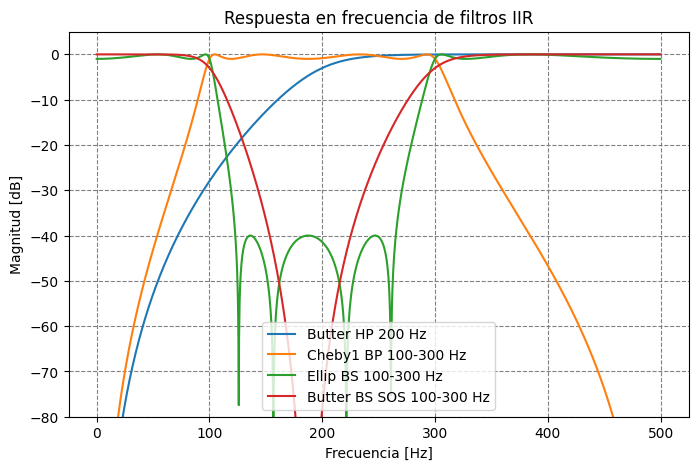

In [ ]:
# Butterworth High-pass @ 200 Hz
b_hp, a_hp = butter(order_iir, 200/nyq, btype='highpass', output='ba')

# Chebyshev I Band-pass 100-300 Hz (ripple 1 dB)
b_bp, a_bp = cheby1(order_iir, 1, [100/nyq, 300/nyq], btype='bandpass', output='ba')

# Elíptico Band-stop 100-300 Hz (ripple 1 dB, atenuación de rechazo 40 dB)
b_bs, a_bs = ellip(order_iir, 1, 40, [100/nyq, 300/nyq], btype='bandstop', output='ba')

# SOS (Second-Order Sections) para mayor estabilidad - Butterworth Band-stop
sos_bs = iirfilter(order_iir, [100/nyq, 300/nyq], btype='bandstop', ftype='butter', output='sos')

# Respuestas en frecuencia
w_hp, h_hp = freqz(b_hp, a_hp, worN=2048, fs=fs)
w_bp, h_bp = freqz(b_bp, a_bp, worN=2048, fs=fs)
w_bs, h_bs = freqz(b_bs, a_bs, worN=2048, fs=fs)
w_sos, h_sos = sosfreqz(sos_bs, worN=2048, fs=fs)

# Gráfica
plt.plot(w_hp, 20*np.log10(np.abs(h_hp)), label='Butter HP 200 Hz')
plt.plot(w_bp, 20*np.log10(np.abs(h_bp)), label='Cheby1 BP 100-300 Hz')
plt.plot(w_bs, 20*np.log10(np.abs(h_bs)), label='Ellip BS 100-300 Hz')
plt.plot(w_sos, 20*np.log10(np.abs(h_sos)), label='Butter BS SOS 100-300 Hz')
plt.title('Respuesta en frecuencia de filtros IIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.ylim(-80, 5)
plt.legend()
plt.grid(True)
plt.show()
